In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


dish_data = pd.read_csv("data/Dish.csv", index_col="id")
dish_data.describe()

,description,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
count,0.0,426740.000000,426740.000000,426740.000000,426740.000000,397639.000000,397639.000000
mean,NaN,3.045430,3.126079,1662.388843,1666.144374,0.957152,1.590395
std,NaN,27.712989,29.854850,665.369340,666.038925,6.686869,12.643656
min,NaN,0.000000,-6.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.000000,1.000000,1900.000000,1900.000000,0.000000,0.000000
50%,NaN,1.000000,1.000000,1914.000000,1917.000000,0.000000,0.000000
75%,NaN,1.000000,1.000000,1949.000000,1955.000000,0.400000,0.550000
max,NaN,7747.000000,8495.000000,2928.000000,2928.000000,1035.000000,3050.000000


Для кластеризации оставим только столбцы 
- `menus_appeared`, 
- `times_appeared`, 
- `first_appeared`, 
- `last_appeared`, 
- `lowest_price`, 
- `highest_price`

In [4]:
dish_data = dish_data.drop(columns="description")
dish_data.head()

,name,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
id,,,,,,,
1,Consomme printaniere royal,8,8,1897,1927,0.20,0.4
2,Chicken gumbo,111,117,1895,1960,0.10,0.8
3,Tomato aux croutons,14,14,1893,1917,0.25,0.4
4,Onion au gratin,41,41,1900,1971,0.25,1.0
5,St. Emilion,66,68,1881,1981,0.00,18.0


In [5]:
# sns.pairplot(dish_data, diag_kind="kde")

Очистка

In [6]:
features = dish_data.dropna(subset=["first_appeared", "last_appeared"])
features = features[(features["menus_appeared"] > 0) & (features["times_appeared"] > 0)]
features = features[(features["first_appeared"] <= 2026) & (features["last_appeared"] <= 2026)]

features = features[(features["lowest_price"].notna()) | (features["highest_price"].notna())]
features["highest_price"] = features["highest_price"].fillna(features["lowest_price"])
features["lowest_price"] = features["lowest_price"].fillna(features["highest_price"])

features["life_time"] = features["last_appeared"] - features["first_appeared"]
features["price_range"] = features["highest_price"] - features["lowest_price"]
features["avg_price"] = (features["highest_price"] + features["lowest_price"]) / 2


features = features[(features["life_time"] > 0) & (features["avg_price"] > 0)]
features["total_appeared"] = features["menus_appeared"] * features["times_appeared"]
features = features.loc[:, ["total_appeared", "life_time", "price_range"]]

In [7]:
features.describe()

,total_appeared,life_time,price_range
count,3.615000e+04,36150.000000,36150.000000
mean,6.466601e+03,31.488437,4.978391
std,1.683597e+05,131.668676,33.363306
min,1.000000e+00,1.000000,0.000000
25%,9.000000e+00,3.000000,0.050000
50%,2.500000e+01,13.000000,0.250000
75%,1.440000e+02,36.000000,1.050000
max,1.989559e+07,2011.000000,3049.550000


In [8]:
# sns.pairplot(features, diag_kind="kde")

In [9]:
X = features.copy()

X = X.apply(lambda x: np.log1p(x))
X.describe()

,total_appeared,life_time,price_range
count,36150.000000,36150.000000,36150.000000
mean,3.841372,2.533089,0.649935
std,2.274808,1.276301,1.036070
min,0.693147,0.693147,0.000000
25%,2.302585,1.386294,0.048790
50%,3.258097,2.639057,0.223144
75%,4.976734,3.610918,0.717840
max,16.806009,7.606885,8.023077


In [27]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_std = StandardScaler().fit_transform(X)
X_mm = MinMaxScaler().fit_transform(X)

print(X_mm)

[[0.2160535  0.39643392 0.02272464]
 [0.54482153 0.50573335 0.06613775]
 [0.28486911 0.36532031 0.01741999]
 ...
 [0.05686704 0.15890281 0.01741999]
 [0.05686704 0.15890281 0.        ]
 [0.05686704 0.1325319  0.04193805]]


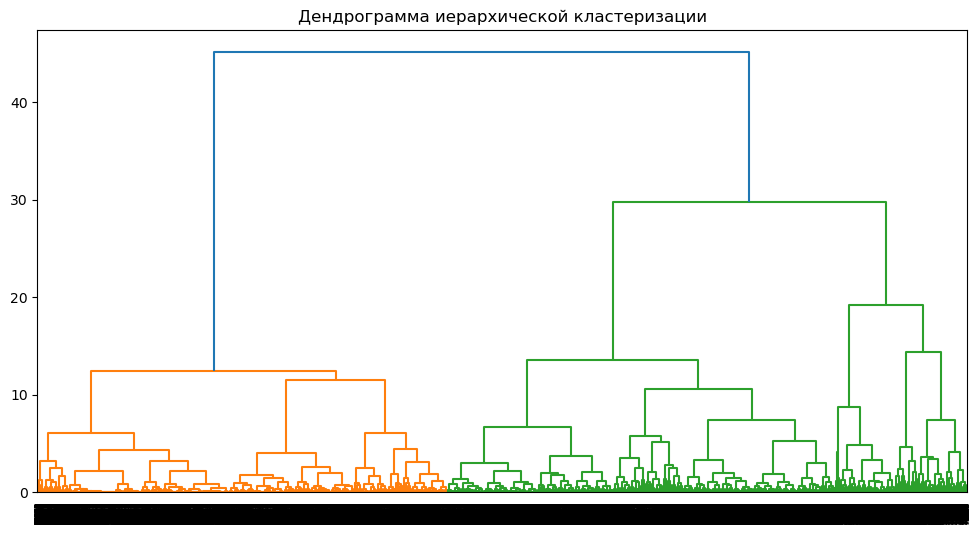

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X_mm, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, p=10)
plt.title('Дендрограмма иерархической кластеризации')
plt.show()

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

<Axes: xlabel='n', ylabel='silhouette_score'>

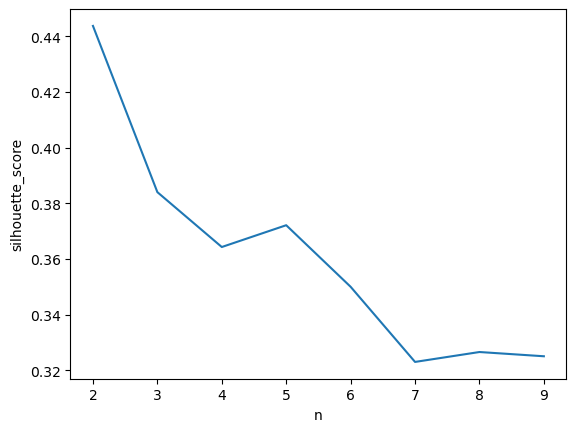

In [32]:
sil_sc = []
inert = []

for n in range(2, 10):
    kmeans = KMeans(n_clusters=n, random_state=42)
    X_kmeans = kmeans.fit(X_std)
    inert.append(X_kmeans.inertia_)

    X_kmeans = kmeans.predict(X_std)
    sil_sc.append([n, silhouette_score(X_std, X_kmeans)])
    
    

df = pd.DataFrame(sil_sc, columns=["n", "silhouette_score"])
sns.lineplot(data=df, x="n", y="silhouette_score")


<Axes: xlabel='n', ylabel='inertia'>

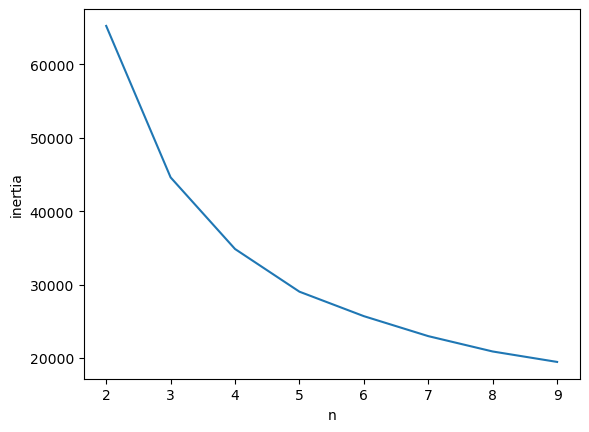

In [33]:
df["inertia"] = inert
sns.lineplot(data=df, x="n", y="inertia")

Inertia - внутриклассовая сумма квадратов
$$Inertia = \sum_{k=1}^K\sum_{x_i \in C_k} ||x_i - \mu_k||^2$$

Silhouette - отношение суммы внутриклассовых расстояний и внешних классов
$$Silhouette = \frac{1}{n}\sum_{i=1}^n \frac{b(i)-a(i)}{max(a(i), b(i))}$$

`The best value is 1 and the worst value is -1. Values near 0 indicate overlapping clusters. Negative values generally indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar.`

Интерпретируя метрики, получаем, что для наших данных interia не подходит, а  silhouette достигает своего максимума в точке $n=2$, следовательно оптимальное число кластеров = 2.

In [34]:
kmeans = KMeans(n_clusters=2)
X_kmeans = kmeans.fit_predict(X_mm)
print(set(X_kmeans))

print(silhouette_score(X_mm, X_kmeans))

{np.int32(0), np.int32(1)}
0.4011798285427753


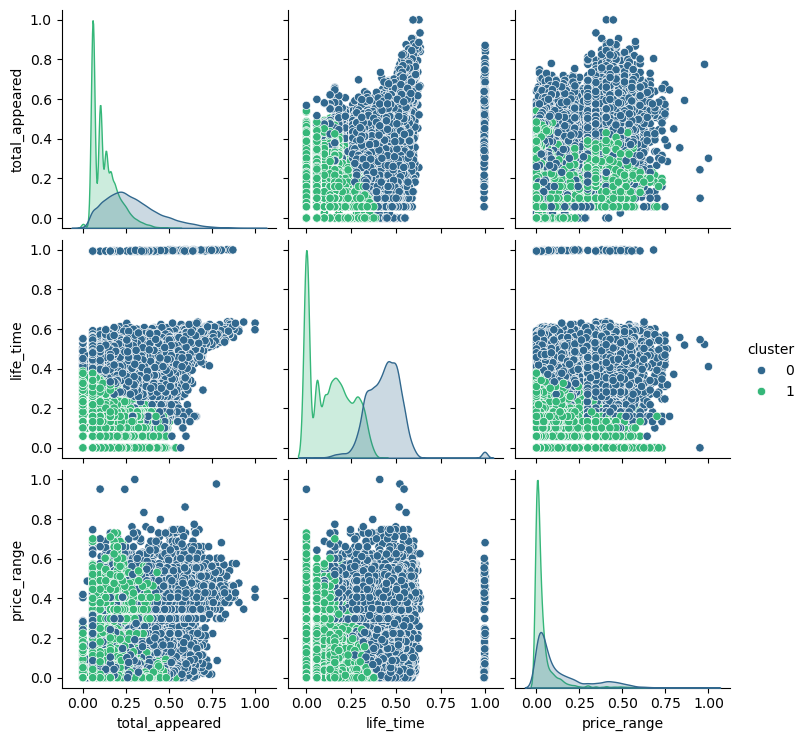

In [35]:
df = pd.DataFrame(X_mm, columns=["total_appeared", "life_time", "price_range"])
df["cluster"] = X_kmeans
sns.pairplot(df, diag_kind="kde", hue="cluster", palette="viridis")

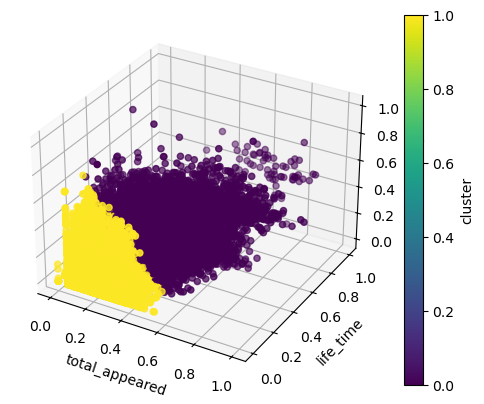

In [39]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = df["total_appeared"]
y = df["life_time"]
z = df["price_range"]
clusters = df["cluster"]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x, y, z, c=clusters, cmap='viridis')

ax.set_xlabel("total_appeared")
ax.set_ylabel("life_time")
ax.set_zlabel("price_range")

plt.colorbar(scatter, label='cluster')
plt.show()

In [ ]:
df.to_csv("./data/dish_data.csv", )

TypeError: 'RangeIndex' object is not callable